# Stage 05a: Initial Model Training

**Purpose:** Quick validation with default hyperparameters

**Inputs:**
- data/04c_train_encoded.parquet
- data/04c_test_encoded.parquet
- data/04c_train_base_margin.parquet
- data/04c_test_base_margin.parquet
- config_generated/04c_monotonicity_constraints.yaml

**Outputs:**
- models/05a_model_initial.json
- results/05a_predictions_train.parquet
- results/05a_predictions_test.parquet
- results/05a_metrics.yaml

In [1]:
config_path = "config/car_coll/v1"

In [2]:
# Parameters
config_path = "config/car_liab/v1"


In [3]:
import matplotlib
matplotlib.use("Agg")

import pandas as pd
import numpy as np
import xgboost as xgb
import yaml, os, sys
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

sys.path.insert(0, str(Path.cwd() / "lib"))
from utils import setup_notebook_environment

print("########################################")
print("# STAGE 05a: INITIAL MODEL TRAINING")
print("########################################")

project_root = setup_notebook_environment()
from model_utils import transform_target, inverse_transform, predict_with_transform, save_predictions

########################################
# STAGE 05a: INITIAL MODEL TRAINING
########################################


In [4]:
print(f"Python: {sys.version}")
print(f"XGBoost: {xgb.__version__}")

Python: 3.11.15 (main, Jun 11 2026, 15:14:57) [Clang 20.1.8 ]
XGBoost: 3.1.1


In [5]:
# Get machine config
pc_num = open("current.pc").read().strip()
pc_id = f"PC{pc_num}"

config_file = f"{config_path}/config.yaml"
with open(config_file, "r") as f:
    cfg = yaml.safe_load(f)

output_base = cfg["machines"][pc_id]["paths"]["output_path"]
target = cfg["experiment"]["target"]
exposure = cfg["experiment"]["exposure"]
target_method = cfg["model"].get("target_method", "direct")
print(f"Target method: {target_method}")

Target method: residual


In [6]:
# Load encoded features (already filtered by exclusions in 04c)
print(f"\n* Loading encoded features...")
X_train = pd.read_parquet(f"{output_base}/data/04c_train_encoded.parquet")
X_test = pd.read_parquet(f"{output_base}/data/04c_test_encoded.parquet")

# Load original data for target/exposure
train_orig = pd.read_parquet(f"{output_base}/data/04b_train.parquet")
test_orig = pd.read_parquet(f"{output_base}/data/04b_test.parquet")

# Load GLM predictions if using residual method
if target_method == "residual":
    glm_train_df = pd.read_parquet(f"{output_base}/data/04c_train_glm.parquet")
    glm_test_df = pd.read_parquet(f"{output_base}/data/04c_test_glm.parquet")
    glm_train = glm_train_df["glm_pred"]
    glm_test = glm_test_df["glm_pred"]
    print(f"  GLM loaded: train mean={glm_train.mean():.2f}, test mean={glm_test.mean():.2f}")
else:
    glm_train = glm_test = None

# Get actual PP
pp_train_actual = train_orig[target]
pp_test_actual = test_orig[target]

# Transform target for GBM training
# Convert to numpy arrays to avoid index alignment issues
y_train = transform_target(pp_train_actual.values, glm_train.values if glm_train is not None else None, target_method)
y_test = transform_target(pp_test_actual.values, glm_test.values if glm_test is not None else None, target_method)
w_train = train_orig[exposure]
w_test = test_orig[exposure]

print(f"  Train: {X_train.shape}")
print(f"  Test: {X_test.shape}")
print(f"  Features: {X_train.shape[1]}")


* Loading encoded features...


  GLM loaded: train mean=217.61, test mean=217.74
  Train: (18709834, 200)
  Test: (7483698, 200)
  Features: 200


In [7]:
# Load base_margin if available
base_margin_file_train = f"{output_base}/data/04c_train_base_margin.parquet"
base_margin_file_test = f"{output_base}/data/04c_test_base_margin.parquet"

if os.path.exists(base_margin_file_train):
    print(f"\n* Loading base_margin...")
    base_margin_train = pd.read_parquet(base_margin_file_train)["base_margin"].values
    base_margin_test = pd.read_parquet(base_margin_file_test)["base_margin"].values
    print(f"  Train base_margin: mean={base_margin_train.mean():.4f}")
    print(f"  Test base_margin: mean={base_margin_test.mean():.4f}")
else:
    base_margin_train = None
    base_margin_test = None
    print(f"\n* No base_margin found (GLM init disabled)")


* No base_margin found (GLM init disabled)


In [8]:
# Load monotonicity constraints
mono_file = f"{output_base}/config_generated/04c_monotonicity_constraints.yaml"
if os.path.exists(mono_file):
    print(f"\n* Loading monotonicity constraints...")
    with open(mono_file, "r") as f:
        mono_dict = yaml.safe_load(f)
    # Build constraints tuple in feature order
    feature_names = X_train.columns.tolist()
    monotone_constraints = tuple(mono_dict.get(f, 0) for f in feature_names)
    n_constrained = sum(1 for c in monotone_constraints if c != 0)
    print(f"  Loaded {n_constrained} constraints")
else:
    monotone_constraints = None
    print(f"\n* No monotonicity constraints found")


* Loading monotonicity constraints...
  Loaded 16 constraints


In [9]:
# Build XGBoost parameters
print(f"\n* Building XGBoost parameters...")
xgb_params = cfg["xgboost"].copy()
n_estimators = xgb_params.pop("n_estimators")

# Add monotonicity constraints if available
if monotone_constraints:
    xgb_params["monotone_constraints"] = monotone_constraints

# Fix eval_metric for tweedie
if "eval_metric" in xgb_params and "tweedie" in xgb_params["eval_metric"]:
    if "@" not in xgb_params["eval_metric"]:
        variance_power = xgb_params["tweedie_variance_power"]
        xgb_params["eval_metric"] = f"{xgb_params['eval_metric']}@{variance_power}"

print(f"  n_estimators: {n_estimators}")
print(f"  monotone_constraints: {monotone_constraints is not None}")


* Building XGBoost parameters...
  n_estimators: 500
  monotone_constraints: True


In [10]:
# Train model
print(f"\n* Training XGBoost model...")

model = xgb.XGBRegressor(n_estimators=n_estimators, **xgb_params)

model.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    sample_weight_eval_set=[w_train, w_test],
    verbose=100
)

print(f"\n* Training complete")
print(f"  Best iteration: {model.best_iteration}")


* Training XGBoost model...


[0]	validation_0-tweedie-nloglik@1.5:3.32378	validation_1-tweedie-nloglik@1.5:3.45624


[100]	validation_0-tweedie-nloglik@1.5:3.09616	validation_1-tweedie-nloglik@1.5:3.29623


[200]	validation_0-tweedie-nloglik@1.5:3.04648	validation_1-tweedie-nloglik@1.5:3.29022


[266]	validation_0-tweedie-nloglik@1.5:3.02144	validation_1-tweedie-nloglik@1.5:3.28975



* Training complete
  Best iteration: 217


In [11]:
# Generate predictions
print(f"\n* Generating predictions...")
# Generate predictions with inverse transform
gbm_train_raw, pred_train = predict_with_transform(model, X_train, glm_train, target_method)
gbm_test_raw, pred_test = predict_with_transform(model, X_test, glm_test, target_method)

print(f"  Predictions: train mean={pred_train.mean():.2f}, test mean={pred_test.mean():.2f}")

# Calculate metrics
mae_train = mean_absolute_error(pp_train_actual, pred_train, sample_weight=w_train)
mae_test = mean_absolute_error(pp_test_actual, pred_test, sample_weight=w_test)
rmse_train = np.sqrt(mean_squared_error(pp_train_actual, pred_train, sample_weight=w_train))
rmse_test = np.sqrt(mean_squared_error(pp_test_actual, pred_test, sample_weight=w_test))

print(f"\n* Metrics:")
print(f"  Train MAE: {mae_train:.4f}, RMSE: {rmse_train:.4f}")
print(f"  Test MAE: {mae_test:.4f}, RMSE: {rmse_test:.4f}")


* Generating predictions...


  Predictions: train mean=243.95, test mean=245.15

* Metrics:
  Train MAE: 277.5196, RMSE: 6628.9371
  Test MAE: 288.0108, RMSE: 6813.7035


In [12]:
# Prepare data for lift charts
import matplotlib.pyplot as plt
from lift_chart_fast import create_lift_chart
from hpo_metrics import compute_fit_quality, compute_model_power
from IPython.display import Image, display

print(f'\n* Preparing lift chart data...')

# Add predictions to original data
train_orig['pred'] = pred_train
test_orig['pred'] = pred_test

# Create columns for lift_chart_fast
# denom = 1 because target (pp_coll) is already pure premium (rate)
# Don't divide by exposure again!
train_orig['incurred_act'] = y_train if isinstance(y_train, np.ndarray) else y_train.values
train_orig['incurred_pred'] = pred_train
train_orig['denom'] = 1

test_orig['incurred_act'] = y_test if isinstance(y_test, np.ndarray) else y_test.values
test_orig['incurred_pred'] = pred_test
test_orig['denom'] = 1

print(f'  Data prepared (denom=1 for pure premium target)')


* Preparing lift chart data...


  Data prepared (denom=1 for pure premium target)



* Creating train lift chart...
  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 5 columns from 18,709,834 rows...
  [STEP 2] Done in 0.106s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 1.9s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.001s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.097s
  [STEP 5] Aggregating by decile...


  [STEP 5] Done in 0.525s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 2.7s
  Saved: output/car_liab/v1/results/05a_lift_train.png


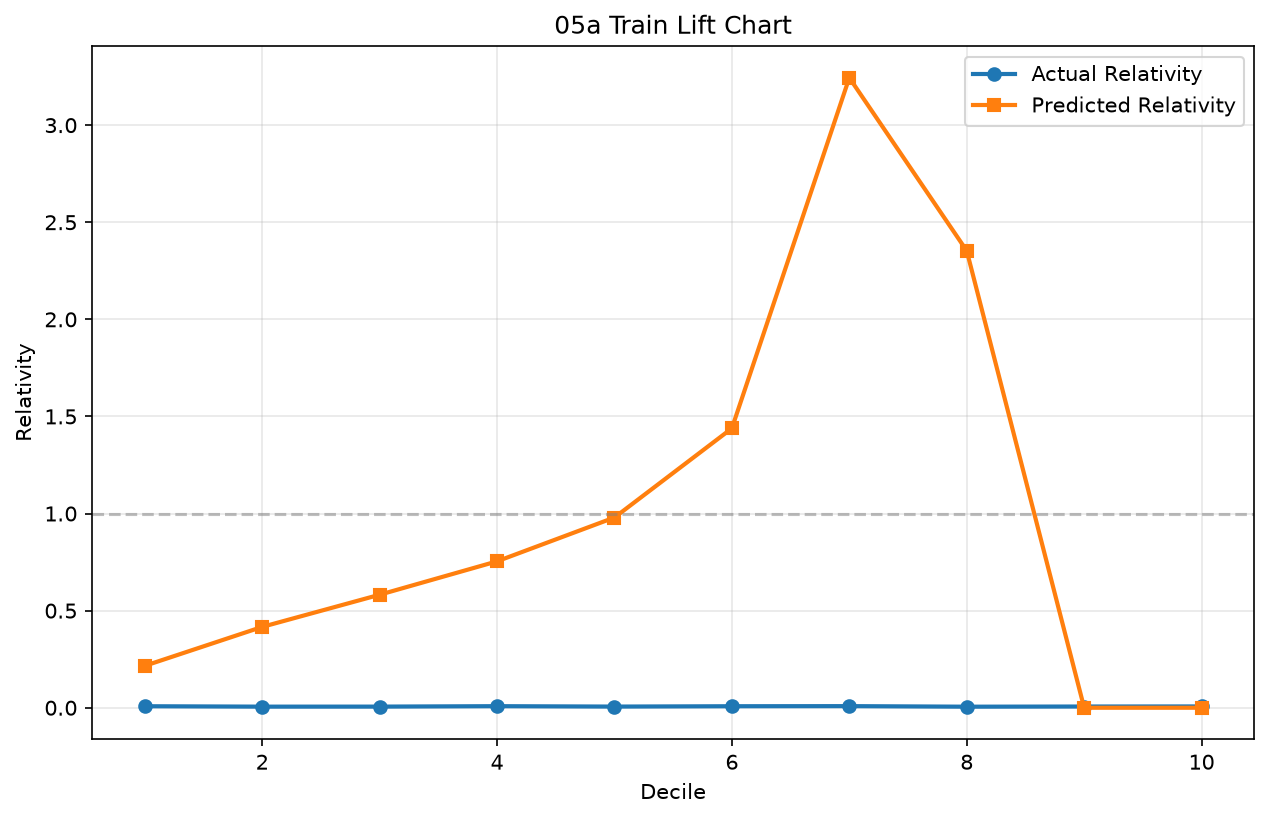


Train decile summary:
 decile      act       pred  act_rel  pred_rel
      1 1.358445  37.606370 0.007798  0.215872
      2 0.993835  72.523716 0.005705  0.416308
      3 1.021653 101.369942 0.005865  0.581894
      4 1.409813 131.337097 0.008093  0.753914
      5 1.047845 170.650638 0.006015  0.979586
      6 1.357957 250.669811 0.007795  1.438920
      7 1.447052 565.141988 0.008307  3.244084
      8 0.949781 409.907497 0.005452  2.352992
      9 1.106904   0.000000 0.006354  0.000000
     10 1.182047   0.000000 0.006785  0.000000


In [13]:
# Train lift chart
print(f'\n* Creating train lift chart...')
fig_train, table_train = create_lift_chart(
    train_orig, 
    exposure,  # weight column for decile binning
    bins=10, 
    title='05a Train Lift Chart'
)

chart_file = f'{output_base}/results/05a_lift_train.png'
fig_train.savefig(chart_file, dpi=150, bbox_inches='tight')
plt.close(fig_train)
print(f'  Saved: {chart_file}')

display(Image(chart_file))
print('\nTrain decile summary:')
print(table_train[['decile', 'act', 'pred', 'act_rel', 'pred_rel']].to_string(index=False))


* Creating test lift chart...
  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 5 columns from 7,483,698 rows...
  [STEP 2] Done in 0.042s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.3s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.041s
  [STEP 5] Aggregating by decile...


  [STEP 5] Done in 0.192s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 0.6s
  Saved: output/car_liab/v1/results/05a_lift_test.png


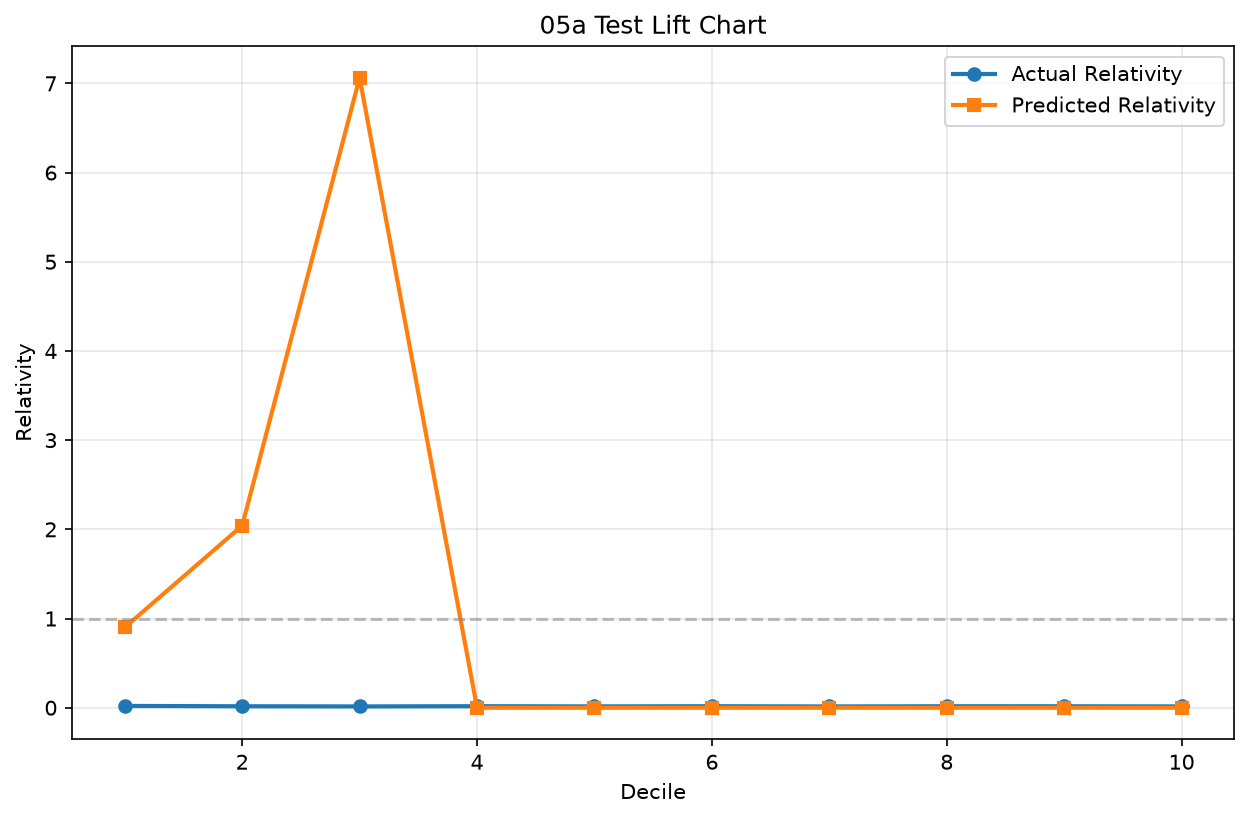


Test decile summary:
 decile      act       pred  act_rel  pred_rel
      1 1.429378  63.128340 0.020379  0.900052
      2 1.164118 143.212782 0.016597  2.041856
      3 1.037713 495.400962 0.014795  7.063179
      4 1.221158   0.000000 0.017411  0.000000
      5 1.062967   0.000000 0.015155  0.000000
      6 1.207488   0.000000 0.017216  0.000000
      7 1.017213   0.000000 0.014503  0.000000
      8 1.176932   0.000000 0.016780  0.000000
      9 1.156305   0.000000 0.016486  0.000000
     10 1.060775   0.000000 0.015124  0.000000


In [14]:
# Test lift chart
print(f'\n* Creating test lift chart...')
fig_test, table_test = create_lift_chart(
    test_orig, 
    exposure,  # weight column for decile binning
    bins=10, 
    title='05a Test Lift Chart'
)

chart_file = f'{output_base}/results/05a_lift_test.png'
fig_test.savefig(chart_file, dpi=150, bbox_inches='tight')
plt.close(fig_test)
print(f'  Saved: {chart_file}')

display(Image(chart_file))
print('\nTest decile summary:')
print(table_test[['decile', 'act', 'pred', 'act_rel', 'pred_rel']].to_string(index=False))

In [15]:
# Calculate actuarial metrics
print(f'\n* Calculating actuarial metrics...')

fit_train = compute_fit_quality(pp_train_actual, pred_train, w_train)
fit_test = compute_fit_quality(pp_test_actual, pred_test, w_test)
power_train = compute_model_power(pp_train_actual, pred_train, w_train)
power_test = compute_model_power(pp_test_actual, pred_test, w_test)

print(f'\n* Actuarial Metrics:')
print(f'  Train:')
print(f'    Fit Quality:  {fit_train:.4f}')
print(f'    Model Power:  {power_train:.4f}')
print(f'  Test:')
print(f'    Fit Quality:  {fit_test:.4f}')
print(f'    Model Power:  {power_test:.4f}')


* Calculating actuarial metrics...



* Actuarial Metrics:
  Train:
    Fit Quality:  -0.1179
    Model Power:  1.1110
  Test:
    Fit Quality:  -0.0371
    Model Power:  1.0241


In [16]:
# Save model
os.makedirs(f"{output_base}/models", exist_ok=True)
model_file = f"{output_base}/models/05a_model_initial.json"
model.get_booster().save_model(model_file)
print(f"\n* Saved model: {model_file}")


* Saved model: output/car_liab/v1/models/05a_model_initial.json


In [17]:
# Save predictions using utility function
print(f"\n* Saving predictions...")
save_predictions(output_base, "05a", "train", pp_train_actual, pred_train, w_train)
save_predictions(output_base, "05a", "test", pp_test_actual, pred_test, w_test)
print("  ✓ Saved")


* Saving predictions...


  ✓ Saved


In [18]:
# Save metrics
metrics = {
    "stage": "05a_initial",
    "train": {"mae": float(mae_train), "rmse": float(rmse_train)},
    "test": {"mae": float(mae_test), "rmse": float(rmse_test)},
    "best_iteration": int(model.best_iteration),
    "n_features": int(X_train.shape[1]),
    "monotone_constraints_applied": monotone_constraints is not None,
    "base_margin_applied": base_margin_train is not None
}

with open(f"{output_base}/results/05a_metrics.yaml", "w") as f:
    yaml.dump(metrics, f)

print(f"* Saved metrics")

* Saved metrics


In [19]:
print("\n########################################")
print("# STAGE 05a: COMPLETE")
print("########################################")


########################################
# STAGE 05a: COMPLETE
########################################
